# Recalculate skills centrality/coreness based on ESCO v.1.0
Felix Zaussinger | 01.09.2022

**Core Analysis Goal(s)**
1. Use Kanders 2021 code to re-calculate skills centrality/coreness for the latest ESCO release (v1.0)
2. Compare GBN categories at skill and occ level
3.

**Key Insight(s)**
1.
2.
3.

In [11]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("poster")
#sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Code ...

In [12]:
import igraph as ig
from src.data.framework import Esco
import scipy
import pingouin as pg
from mapping_career_causeways import cluster_utils
esco = Esco()

#### Read occupation-skills matrix and calculate skills-skills matrix
- [igraph docs](https://igraph.org/python/tutorial/latest/tutorial.html#treating-a-graph-as-an-adjacency-matrix)
- In adjacency matrix, rows and columns are labeled by graph vertices: the elements of the matrix indicate whether the vertices i and j have a common edge (i, j). The adjacency matrix for the example graph is

In [13]:
%%time

# choose OSM version (weighted/unweighted)
osm_version = "unweighted"

# read bipartite adjecency matrix for occupations and skills
osm = esco.read_occ_skills_matrix(return_version=osm_version)
osm_sparse = scipy.sparse.csr_matrix(osm.values)

# Co-occurrence matrix
W_sparse = osm_sparse.T.dot(osm_sparse)
W = W_sparse.toarray()
np.fill_diagonal(W,0)

# Adjacency matrix of the co-occurrence graph
A = np.zeros(W.shape)
A[W!=0] = 1

CPU times: total: 3.28 s
Wall time: 3.63 s


In [14]:
np.unique(osm.values.flatten())

array([0, 1], dtype=int64)

Build graph

In [15]:
%%time
graph = cluster_utils.build_graph(W, A)

Building the graph... done!


#### Calculate 'coreness' (might take a few minutes)

- **Eigenvector centrality**
    - how important is a node (skill) together with the importance (weight?) of its neighbours (and their neighbours...)?
    - can identify nodes with influence over the whole network, not just those directly connected to it.

- **Betweenness centrality**
    - how often does a node (skill) lie on the shortest paths between two other nodes (skills)?
    - This measure shows which nodes are ‘bridges’ between nodes in a network.

![Centrality comparison 1](../../references/Example-of-eigenvector-centrality.png)
[Ref](https://www.researchgate.net/figure/Example-of-eigenvector-centrality_fig1_311975848)

![Centrality comparison 2](../../references/Pictorial-description-of-In-degree-Eigenvector-centrality-and-betweenness-centrality.png)
[Ref](https://www.researchgate.net/figure/Pictorial-description-of-In-degree-Eigenvector-centrality-and-betweenness-centrality_fig1_313416055)

- **Clustering coefficient**
    - how well are the neighbours of a node (skills) connected?
    - degree to which nodes in a graph tend to cluster together
    - abundance of connected triangles in a network
    - extent to which edges of a network cluster in terms of triangles

![Clustering coefficient](../../references/An-example-of-clustering-coefficient-Three-network-configurations-that-result-in.png)
[Ref](https://www.researchgate.net/figure/An-example-of-clustering-coefficient-Three-network-configurations-that-result-in_fig2_324745118)

In [16]:
# Eigenvector centrality, e
centrality_unweighted = graph.evcent(directed=False, scale=True, weights=None)

# Betweenness centrality, b
betweenness = graph.betweenness(directed=False)

# Clustering coefficient, c
clustering_coeff = graph.transitivity_local_undirected()

# Normalise betweenness centrality between 0 and 1, b_norm
betweenness_norm = np.array(betweenness) / np.max(betweenness)

# Average b_norm and e
mean_centrality = 0.5*np.array(betweenness_norm) + 0.5*np.array(centrality_unweighted)

# Multiply averaged centarlity with (1-c) to select skills that are high on both measures
m = mean_centrality*(1-np.array(clustering_coeff))

# Deal with nulls
m[np.where(np.isnan(m))[0]] = 0

# Normalise between 0 and 1
m = m / np.max(m)

In [17]:
network_metrics = pd.DataFrame(
    columns=osm.columns.values,
    data=[centrality_unweighted, betweenness, betweenness_norm, mean_centrality, clustering_coeff, m],
    index=["eigenvector_centrality", "betweenness_centrality", "betweenness_centrality_norm", "mean_centrality", "clustering_coefficient", "coreness"]
).T
network_metrics.index.name = "conceptUri"

# Merge with ESCO skills metadata
esco_skill_clsf = esco.combine_skills_metadata().loc[:, ("conceptUri", "skill_classification_esco")]
skills_network_metrics = pd.merge(esco.skills, network_metrics.reset_index(), on="conceptUri", how="left")
skills_network_metrics_gbn = pd.merge(skills_network_metrics, esco_skill_clsf, on="conceptUri", how="left")

# save
utils.save_df_to_files(
    df=skills_network_metrics_gbn,
    fname_no_ext="skills_network_metrics_{}".format(osm_version),
    output_dir=os.path.join(useful_paths.data_processed, "esco")
)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


#### Descriptive stats

In [18]:
skills_network_metrics_gbn.describe()

,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness
count,13891.000000,1.389100e+04,13891.000000,13891.000000,13021.000000,13891.000000
mean,0.065726,7.820385e+03,0.002980,0.034353,0.693411,0.021247
std,0.101109,6.088728e+04,0.023198,0.056899,0.253144,0.051396
min,0.000000,0.000000e+00,0.000000,0.000000,0.060475,0.000000
25%,0.010394,0.000000e+00,0.000000,0.005217,0.495557,0.000000
50%,0.024489,1.934840e+02,0.000074,0.012384,0.693452,0.003914
75%,0.074658,1.590170e+03,0.000606,0.038046,0.992902,0.017893
max,1.000000,2.624645e+06,1.000000,0.913037,1.000000,1.000000


In [25]:
skills_network_metrics_gbn.groupby("skill_classification_esco").describe()

eigenvector_centrality                           \
                                           count      mean       std  min   
skill_classification_esco                                                   
brown                                      477.0  0.035895  0.062296  0.0   
green                                      570.0  0.127981  0.131144  0.0   
neutral                                  12844.0  0.064072  0.099714  0.0   

                                                                   \
                                25%       50%       75%       max   
skill_classification_esco                                           
brown                      0.006532  0.014192  0.033270  0.415611   
green                      0.028281  0.072567  0.201377  0.681498   
neutral                    0.010354  0.023978  0.073686  1.000000   

                          betweenness_centrality                             \
                                           count         mean           std   
skill_classification_esco                                                     
brown                                      477.0  1849.248729   8566.455701   
green                                      570.0  8013.899885  27950.835331   
neutral                                  12844.0  8033.552820  63014.153091   

                                                                    \
                           min        25%         50%          75%   
skill_classification_esco                                            
brown                      0.0   0.000000   66.806142   565.794028   
green                      0.0  79.227897  877.448420  4032.574486   
neutral                    0.0   0.000000  186.137853  1567.725187   

                                        betweenness_centrality_norm            \
                                    max                       count      mean   
skill_classification_esco                                                       
brown                      1.261953e+05                       477.0  0.000705   
green                      3.444851e+05                       570.0  0.003053   
neutral                    2.624645e+06                     12844.0  0.003061   

                                                                       \
                                std  min      25%       50%       75%   
skill_classification_esco                                               
brown                      0.003264  0.0  0.00000  0.000025  0.000216   
green                      0.010649  0.0  0.00003  0.000334  0.001536   
neutral                    0.024009  0.0  0.00000  0.000071  0.000597   

                                    mean_centrality                           \
                                max           count      mean       std  min   
skill_classification_esco                                                      
brown                      0.048081           477.0  0.018300  0.032205  0.0   
green                      0.131250           570.0  0.065517  0.068121  0.0   
neutral                    1.000000         12844.0  0.033566  0.056604  0.0   

                                                                   \
                                25%       50%       75%       max   
skill_classification_esco                                           
brown                      0.003279  0.007096  0.016751  0.231846   
green                      0.014480  0.036995  0.102079  0.395470   
neutral                    0.005199  0.012116  0.037276  0.913037   

                          clustering_coefficient                      \
                                           count      mean       std   
skill_classification_esco                                              
brown                                      462.0  0.756318  0.228800   
green                                      558.0  0.609013  0.239025   
neutral                                  12001.0  0.694913  0.253732  

In [19]:
skills_network_metrics_gbn.rcorr()

,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness
eigenvector_centrality,-,***,***,***,***,***
betweenness_centrality,0.467,-,***,***,***,***
betweenness_centrality_norm,0.467,1.0,-,***,***,***
mean_centrality,0.984,0.618,0.618,-,***,***
clustering_coefficient,-0.553,-0.261,-0.261,-0.544,-,***
coreness,0.908,0.736,0.736,0.957,-0.567,-


#### Maximum spanning tree (Hidalgo 2007)
- I have a graph and want to obtain the maximum spanning tree, therefore I obtain the minimum spanning tree of the graph with inverse weights. ([REF](https://stackoverflow.com/questions/46103615/igraph-maximum-spanning-tree-is-disconnected))

In [20]:
graph.is_directed()

False

In [21]:
graph.is_connected(mode="weak")

False

In [22]:
inv_weight = [1./w for w in graph.es["weight"]]

In [23]:
MST = graph.spanning_tree(weights=inv_weight)

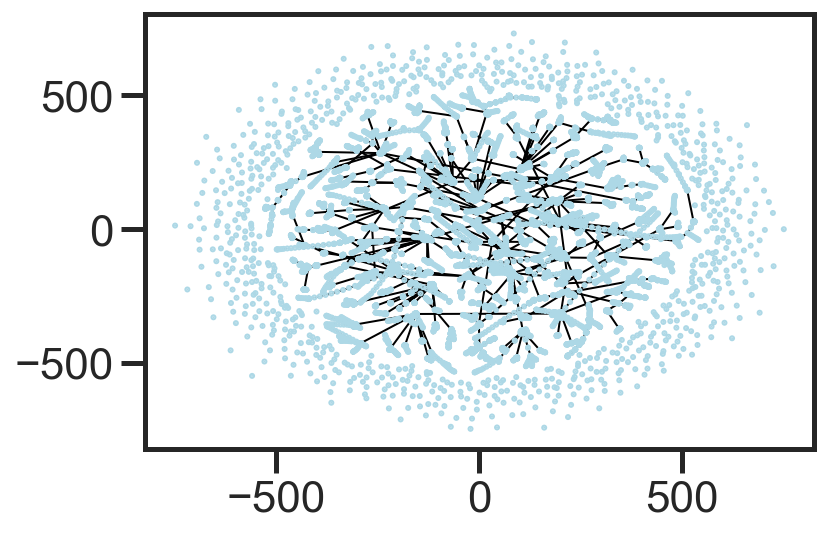

In [30]:
fig, ax = plt.subplots()
ig.plot(
    MST,
    target=ax,
    vertex_color="lightblue",
    vertex_size=1,
)

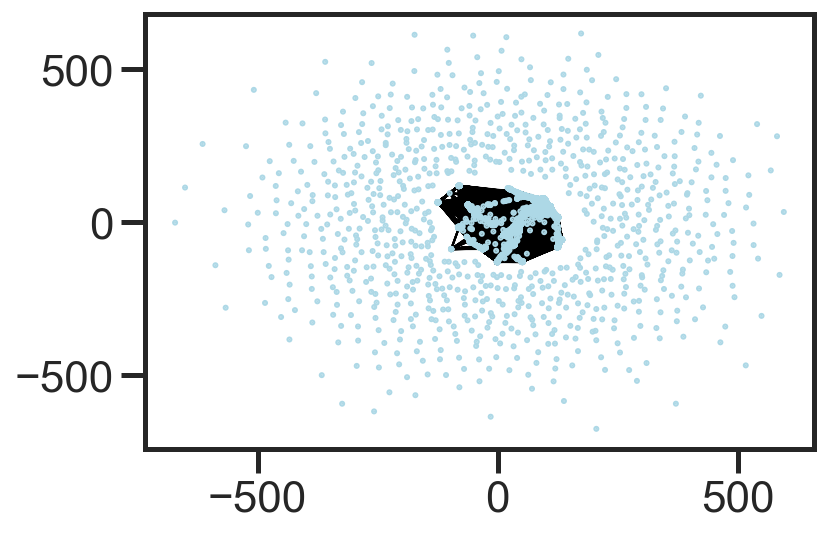

In [31]:
fig, ax = plt.subplots()
ig.plot(
    graph,
    target=ax,
    vertex_color="lightblue",
    vertex_size=1,
)